In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
classes = ['angry','disgust','fear','happy','neutral','sad','surprise']
counts = [3993,436,4103,7164,4982,4938,3205]

In [ ]:
target_size = (224, 224)

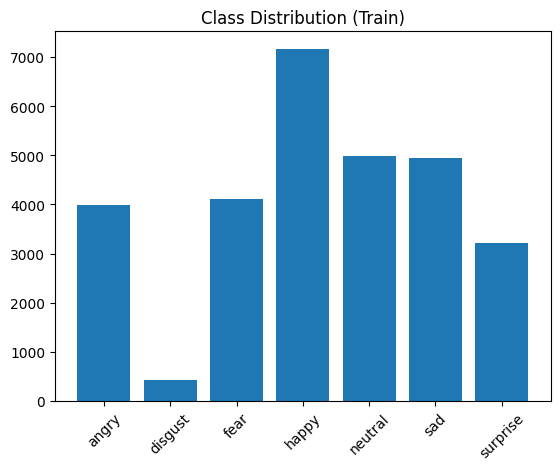

In [ ]:
import matplotlib.pyplot as plt

classes = ['angry','disgust','fear','happy','neutral','sad','surprise']
counts = [3993,436,4103,7164,4982,4938,3205]

plt.bar(classes, counts)
plt.title("Class Distribution (Train)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os

print("Current Directory:", os.getcwd())
print("Folders:", os.listdir())

Current Directory: /content
Folders: ['.config', 'sample_data']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')  # 7 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_path = "images/train"
val_path = "images/validation"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    print(root)

.
./.config
./.config/logs
./.config/logs/2026.04.16
./.config/configurations
./sample_data


In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile

for file in uploaded.keys():
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall("dataset")

In [ ]:
import os
print(os.listdir("dataset"))

In [ ]:
train_path = "dataset/images/train"
val_path = "dataset/images/validation"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.3039 - loss: 1.7303 - val_accuracy: 0.4049 - val_loss: 1.5464
Epoch 2/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4028 - loss: 1.5270 - val_accuracy: 0.4643 - val_loss: 1.4079
Epoch 3/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.4602 - loss: 1.3936 - val_accuracy: 0.4829 - val_loss: 1.3712
Epoch 4/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.5067 - loss: 1.2673 - val_accuracy: 0.4919 - val_loss: 1.3840
Epoch 5/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.5491 - loss: 1.1495 - val_accuracy: 0.5048 - val_loss: 1.3837
Epoch 6/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.5943 - loss: 1.0370 - val_accuracy: 0.5048 - val_loss: 1.4348
Epoch 7/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.6377 - loss: 0.9232 - val_accuracy: 0.5040 - val_loss: 1.4938
Epoch 8/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.6673 - loss: 0.8320 - 

In [ ]:
# Accuracy and Loss Graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('/content/test.jpg', target_size=(48,48))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(val_data)
y_pred = predictions.argmax(axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
model.save("facial_expression_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("facial_expression_model.h5")

In [ ]:
pip install opencv-python